# 03 — Logistic-Regression Scorecard (German Credit)

**Goal:** build a real credit scorecard end to end:
1. WoE-encode every feature, learning WoE **from training data only** (no leakage).
2. Fit logistic regression to predict probability of default (PD).
3. Evaluate with the metrics lenders actually use: **AUC, Gini, KS**.
4. Convert the model into an **integer points scorecard** — the format a loan officer sees.
5. Score sample applicants and see how an approval cutoff trades off volume vs risk.

Two cells are `TODO (YOU)`.

## 1. Setup + load

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import ks_2samp

from src.data_loader import load_german_credit, GERMAN_CATEGORICAL, GERMAN_NUMERIC

df = load_german_credit()
print("shape:", df.shape, "| default rate:", round(df["default"].mean(), 3))
print("categorical:", len(GERMAN_CATEGORICAL), "| numeric:", len(GERMAN_NUMERIC))

shape: (1000, 22) | default rate: 0.3
categorical: 13 | numeric: 7


## 2. Split FIRST (this is the anti-leakage step)

We split into train/test **before** computing any WoE. `stratify=y` keeps the 30% default rate in
both halves — important with imbalanced data so the test set isn't accidentally all-good.

In [2]:
y = df["default"]
X = df.drop(columns=["default", "target"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)

train = X_train.copy(); train["default"] = y_train
test  = X_test.copy();  test["default"]  = y_test
print("train:", train.shape, "default rate", round(train["default"].mean(), 3))
print("test: ", test.shape,  "default rate", round(test["default"].mean(), 3))

train: (800, 21) default rate 0.3
test:  (200, 21) default rate 0.3


## 3. Helpers: binning + WoE (fit on train, apply to test)

`fit_bins` learns quantile bin edges from the **training** numeric column and pins the outer edges
to +/- infinity so any test value (even outside the training range) still lands in a bin.
`woe_iv` is the same function from notebook 02.

In [3]:
def fit_bins(series, q=5):
    """Learn quantile bin edges from a training numeric series."""
    _, edges = pd.qcut(series, q=q, duplicates="drop", retbins=True)
    edges = edges.astype(float).copy()
    edges[0], edges[-1] = -np.inf, np.inf     # catch out-of-range test values
    return edges

def apply_bins(series, edges):
    return pd.cut(series, bins=edges)

def woe_iv(frame, feature, target="default", eps=0.5):
    grp = frame.groupby(feature, observed=True)[target]
    t = pd.DataFrame({"n": grp.size(), "n_bad": grp.sum()})
    t["n_good"] = t["n"] - t["n_bad"]
    t["dist_good"] = (t["n_good"] + eps) / t["n_good"].sum()
    t["dist_bad"]  = (t["n_bad"]  + eps) / t["n_bad"].sum()
    t["woe"] = np.log(t["dist_good"] / t["dist_bad"])
    t["iv_component"] = (t["dist_good"] - t["dist_bad"]) * t["woe"]
    return t, t["iv_component"].sum()

print("helpers ready")

helpers ready


## 4. Encode all 20 features to WoE

For each feature we learn, **from train only**: (a) bin edges if numeric, (b) a category-to-WoE map.
We store both so we can apply the identical transform to test. Any category unseen in train maps to
WoE 0 (neutral). The result: `Xtr` / `Xte`, matrices of 20 WoE columns ready for the model.

In [4]:
bin_edges = {}     # feature -> edges  (numeric only)
woe_maps  = {}     # feature -> {category: woe}
iv_table  = {}     # feature -> IV (train)

train_enc = pd.DataFrame(index=train.index)
test_enc  = pd.DataFrame(index=test.index)

for feat in GERMAN_CATEGORICAL + GERMAN_NUMERIC:
    tr_col, te_col = train[feat], test[feat]
    if feat in GERMAN_NUMERIC:
        edges = fit_bins(tr_col, q=5)
        bin_edges[feat] = edges
        tr_col = apply_bins(tr_col, edges)
        te_col = apply_bins(te_col, edges)

    tmp = pd.DataFrame({feat: tr_col, "default": train["default"].values}, index=train.index)
    wtab, iv = woe_iv(tmp, feat)
    wmap = wtab["woe"].to_dict()
    woe_maps[feat] = wmap
    iv_table[feat] = iv

    train_enc[feat] = pd.Series(tr_col, index=train.index).map(wmap).fillna(0.0)
    test_enc[feat]  = pd.Series(te_col,  index=test.index ).map(wmap).fillna(0.0)

Xtr, Xte = train_enc.values, test_enc.values
print("encoded matrices:", Xtr.shape, Xte.shape)
print("\ntop features by IV (train):")
print(pd.Series(iv_table).sort_values(ascending=False).head(6).round(3).to_string())

encoded matrices: (800, 20) (200, 20)

top features by IV (train):
checking_status    0.613
credit_history     0.264
savings_status     0.216
duration_months    0.215
purpose            0.152
property           0.146


## 5. Fit logistic regression

Plain logistic regression on the WoE features. Because WoE is `ln(good/bad)`, a **higher** WoE means
safer, so it should **lower** the odds of default — expect the coefficients to come out **negative**.

In [5]:
clf = LogisticRegression(max_iter=1000)
clf.fit(Xtr, y_train)

coefs = pd.Series(clf.coef_[0], index=train_enc.columns).sort_values()
print("intercept:", round(clf.intercept_[0], 4))
print("\ncoefficients (mostly negative = higher WoE lowers PD):")
print(coefs.round(3).to_string())

intercept: -0.9055

coefficients (mostly negative = higher WoE lowers PD):
installment_rate      -1.331
personal_status_sex   -0.934
purpose               -0.902
duration_months       -0.848
savings_status        -0.832
telephone             -0.795
foreign_worker        -0.769
other_installment     -0.768
checking_status       -0.767
other_debtors         -0.680
credit_history        -0.675
employment_since      -0.609
credit_amount         -0.548
age_years             -0.499
property              -0.411
housing               -0.383
existing_credits      -0.075
num_dependents         0.000
residence_since        0.020
job                    0.399


## 6. Evaluate: AUC, Gini, KS

- **AUC** (area under the ROC curve): probability the model ranks a random defaulter as riskier than
  a random repayer. 0.5 = coin flip, 1.0 = perfect. The brief's Phase-1 target intuition: >0.75 is good.
- **Gini** = 2·AUC − 1: the same information rescaled so 0 = useless, 1 = perfect. Common in banking.
- **KS**: the biggest gap between the cumulative score distributions of goods and bads. Higher = the
  model separates the two groups more cleanly.

AUC  = 0.8035
Gini = 0.6069
KS   = 0.5762


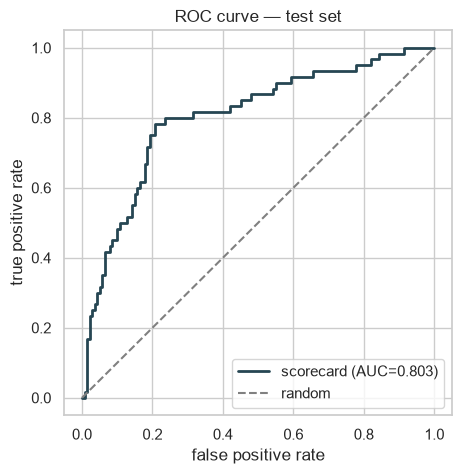

In [6]:
pd_test = clf.predict_proba(Xte)[:, 1]     # predicted probability of default

auc  = roc_auc_score(y_test, pd_test)
gini = 2 * auc - 1
ks   = ks_2samp(pd_test[y_test == 1], pd_test[y_test == 0]).statistic

print(f"AUC  = {auc:.4f}")
print(f"Gini = {gini:.4f}")
print(f"KS   = {ks:.4f}")

fpr, tpr, _ = roc_curve(y_test, pd_test)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, color="#264653", lw=2, label=f"scorecard (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="grey", label="random")
ax.set_xlabel("false positive rate"); ax.set_ylabel("true positive rate")
ax.set_title("ROC curve — test set"); ax.legend()
plt.show()

**TODO (YOU):** Gini is just a rescaling of AUC. Compute it yourself from `auc` and confirm it
matches the printed value above. (One line.)

In [7]:
# TODO (YOU): compute Gini from auc
my_gini = 0.6069
print("my_gini =", round(my_gini, 4), "| should equal", round(gini, 4))

my_gini = 0.6069 | should equal 0.6069


## 7. Build the scorecard (points per attribute)

Now the payoff. We scale the log-odds into points so that **higher score = safer**. Three knobs:
- `base_score` = 500: the anchor score...
- ...at `base_odds` = the portfolio's own good:bad odds (~2.33 here, since 70% repay). So a borrower
  of exactly average risk scores 500. (The famous "600 at 50:1" FICO-style anchor assumes a ~2%
  default book; our teaching dataset defaults 30%, so we anchor to its real odds instead.)
- `pdo` = 40: **P**oints to **D**ouble the **O**dds — every 40 points, odds of being good double.

`Factor = pdo / ln(2)`, `Offset = base_score - Factor * ln(base_odds)`. Each attribute's points are
`(Offset - Factor*intercept)/n  -  Factor * coef * WoE`, distributed across the `n` features. The
minus sign flips the PD model into a "higher = safer" score.

In [8]:
base_score, pdo = 500, 40
base_odds = (y_train == 0).sum() / (y_train == 1).sum()   # portfolio good:bad odds
print("base_odds (good:bad) =", round(base_odds, 3))
factor = pdo / np.log(2)
offset = base_score - factor * np.log(base_odds)

feat_names = list(train_enc.columns)
n = len(feat_names)
coef_map = dict(zip(feat_names, clf.coef_[0]))
intercept = clf.intercept_[0]

def points_for(feature, woe_value):
    base = (offset - factor * intercept) / n
    return base - factor * coef_map[feature] * woe_value

# scorecard: feature -> {category: integer points}
scorecard = {}
for feat in feat_names:
    scorecard[feat] = {cat: int(round(points_for(feat, w))) for cat, w in woe_maps[feat].items()}

# show one feature's scorecard: safer categories should score higher
sc = pd.Series(scorecard["checking_status"]).sort_values(ascending=False)
print("Scorecard — checking_status (higher = safer):")
print(sc.to_string())

base_odds (good:bad) = 2.333
Scorecard — checking_status (higher = safer):
no account    75
>= 200 DM     34
0-200 DM       7
< 0 DM        -9


Sanity check: `no account` (lowest default rate) should top this mini-scorecard and `< 0 DM`
should sit at the bottom. That ordering is the proof the sign is right.

In [9]:
def score_applicant(row_encoded_woe):
    """Total score = sum of per-feature points from that borrower's WoE values."""
    total = 0.0
    for feat in feat_names:
        total += points_for(feat, row_encoded_woe[feat])
    return total

# score the whole test set straight from the WoE matrix
test_scores = (offset - factor * intercept) - factor * (Xte @ clf.coef_[0])

test_out = pd.DataFrame({"score": test_scores, "PD": pd_test, "default": y_test.values})
print(test_out.describe().round(2).to_string())

        score      PD  default
count  200.00  200.00   200.00
mean   516.67    0.30     0.30
std     80.00    0.23     0.46
min    341.92    0.01     0.00
25%    461.86    0.11     0.00
50%    512.52    0.26     0.00
75%    572.65    0.45     1.00
max    717.15    0.87     1.00


Higher score should mean lower PD and fewer actual defaults. Let's see the score distributions
of the two groups pull apart — that visual gap is exactly what KS measures numerically.

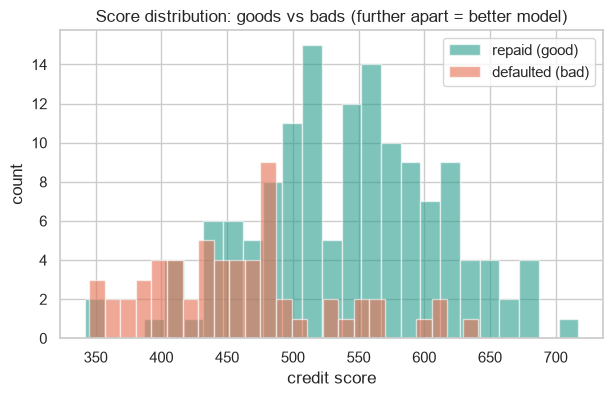

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(test_out.loc[test_out.default == 0, "score"], bins=25, alpha=0.6,
        label="repaid (good)", color="#2a9d8f")
ax.hist(test_out.loc[test_out.default == 1, "score"], bins=25, alpha=0.6,
        label="defaulted (bad)", color="#e76f51")
ax.set_xlabel("credit score"); ax.set_ylabel("count")
ax.set_title("Score distribution: goods vs bads (further apart = better model)")
ax.legend()
plt.show()

## 8. The business decision: where to set the cutoff

The model gives a score; the **lender** picks the approve/reject cutoff. A high cutoff rejects more
people but the approved pool defaults less. A low cutoff approves more but takes on more risk. Let's
quantify that trade-off at one cutoff, then you try another.

In [11]:
def cutoff_report(cutoff):
    approved = test_out[test_out.score >= cutoff]
    rejected = test_out[test_out.score <  cutoff]
    appr_rate = len(approved) / len(test_out)
    bad_appr  = approved["default"].mean() if len(approved) else float("nan")
    bad_rej   = rejected["default"].mean() if len(rejected) else float("nan")
    print(f"cutoff {cutoff}: approve {appr_rate:.0%} of applicants | "
          f"default rate among APPROVED {bad_appr:.1%} | among REJECTED {bad_rej:.1%}")

cutoff_report(500)

cutoff 500: approve 56% of applicants | default rate among APPROVED 10.7% | among REJECTED 54.5%


**TODO (YOU):** call `cutoff_report(...)` with a couple of different cutoffs (try one lower like
480 and one higher like 540). Watch how approval rate and the approved-pool default rate move in
opposite directions. Which cutoff would you pick if the bank told you "keep defaults among approved
loans under 20%"? (Notice even a loose cutoff already beats the 30% book-wide default rate.)

In [16]:
# TODO (YOU): try at least two cutoffs and reason about the trade-off
cutoff_report(480)
cutoff_report(550)

cutoff 480: approve 65% of applicants | default rate among APPROVED 13.1% | among REJECTED 61.4%
cutoff 550: approve 36% of applicants | default rate among APPROVED 11.1% | among REJECTED 40.6%


## 9. Recap — what you built

- A full **WoE -> logistic regression -> points scorecard** pipeline, the classical credit-scoring
  workflow end to end.
- **Anti-leakage discipline:** WoE and bin edges learned on train only, applied to test. This is the
  habit that separates trustworthy AUC from fantasy AUC.
- **AUC / Gini / KS** — the metrics that replace accuracy for imbalanced credit data.
- The **points scorecard**: `points ~ scale x (coef x WoE)`, higher = safer, with `no account`
  topping checking_status exactly as expected.
- The **cutoff is a business lever**, not a model output — you saw approval volume trade against
  approved-pool default rate.

**Next session:** move to **Give Me Some Credit** (250k borrowers) from Kaggle. We'll set up your
`kaggle.json` token, download it, rerun EDA at scale, and then meet **XGBoost** — the gradient-boosted
model that will out-AUC this scorecard and become the primary competitor for deep learning to beat.